<a href="https://colab.research.google.com/github/haya20-ui/ai-project/blob/main/EDA_E_Commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [7]:
from google.colab import files
uploaded = files.upload()  # run this and select all 6 CSVs from your Desktop

Saving customers copy.csv to customers copy.csv
Saving order_items copy.csv to order_items copy.csv
Saving order_payments copy.csv to order_payments copy.csv
Saving order_reviews copy.csv to order_reviews copy.csv
Saving orders copy.csv to orders copy.csv
Saving products copy.csv to products copy.csv


In [10]:
import pandas as pd

orders = pd.read_csv("orders copy.csv")
order_items = pd.read_csv("order_items copy.csv")
order_payments = pd.read_csv("order_payments copy.csv")
order_reviews = pd.read_csv("order_reviews copy.csv")
customers = pd.read_csv("customers copy.csv")
products = pd.read_csv("products copy.csv")

print("✓ All files loaded successfully!")


✓ All files loaded successfully!


In [11]:
# ============================================
# Q1: Dataset Overview
# ============================================

# List all datasets with their names
datasets = {
    "ORDERS": orders,
    "ORDER_ITEMS": order_items,
    "ORDER_PAYMENTS": order_payments,
    "ORDER_REVIEWS": order_reviews,
    "CUSTOMERS": customers,
    "PRODUCTS": products
}

# Display overview for each
for name, df in datasets.items():
    print("\n" + "="*70)
    print(f" {name}")
    print("="*70)

    # 1. Shape (rows, columns)
    print(f"\n Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")

    # 2. Column names
    print(f"\n Column Names:")
    for col in df.columns:
        print(f"   • {col}")

    # 3. First 5 rows
    print(f"\n First 5 rows:")
    display(df.head())

    print("\n" + "-"*70)


 ORDERS

 Shape: 99,441 rows, 8 columns

 Column Names:
   • order_id
   • customer_id
   • order_status
   • order_purchase_timestamp
   • order_approved_at
   • order_delivered_carrier_date
   • order_delivered_customer_date
   • order_estimated_delivery_date

 First 5 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



----------------------------------------------------------------------

 ORDER_ITEMS

 Shape: 112,650 rows, 7 columns

 Column Names:
   • order_id
   • order_item_id
   • product_id
   • seller_id
   • shipping_limit_date
   • price
   • freight_value

 First 5 rows:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



----------------------------------------------------------------------

 ORDER_PAYMENTS

 Shape: 103,886 rows, 5 columns

 Column Names:
   • order_id
   • payment_sequential
   • payment_type
   • payment_installments
   • payment_value

 First 5 rows:


...


----------------------------------------------------------------------

 CUSTOMERS

 Shape: 99,441 rows, 5 columns

 Column Names:
   • customer_id
   • customer_unique_id
   • customer_zip_code_prefix
   • customer_city
   • customer_state

 First 5 rows:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



----------------------------------------------------------------------

 PRODUCTS

 Shape: 32,951 rows, 9 columns

 Column Names:
   • product_id
   • product_category_name
   • product_name_lenght
   • product_description_lenght
   • product_photos_qty
   • product_weight_g
   • product_length_cm
   • product_height_cm
   • product_width_cm

 First 5 rows:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



----------------------------------------------------------------------


In [13]:
# Q2: Column Understanding (Bullet list)
tables = {
    "ORDERS": ["id: Unique (Cat/Uniq)", "cust_id: Link (Cat/FK)", "status: 8 types (Cat)", "purchase: Created (Date)", "approved: Paid (Date/Null)", "carrier: Ship (Date/Null)", "delivered: Recv (Date/Null)", "estimate: Due (Date)"],
    "ITEMS": ["id: Order link (Cat)", "seq: Item # (Num/Pos)", "prod_id: Link (Cat)", "seller: Link (Cat)", "limit: Deadline (Date)", "price: Cost (Num)", "freight: Ship cost (Num)"],
    "PAYMENTS": ["id: Order link (Cat)", "seq: Pay # (Num/Pos)", "type: 4 methods (Cat)", "install: Count (Num)", "value: Total (Num)"],
    "REVIEWS": ["id: Unique (Cat/Uniq)", "score: 1-5 (Num)", "title/msg: Text (Cat/Null)", "created: Date (Date)", "answer: Seller reply (Date/Null)"],
    "CUSTOMERS": ["id: Order-key (Cat)", "uniq_id: Person-key (Cat)", "zip: 5-digit (Num)", "city/state: Location (Cat)"],
    "PRODUCTS": ["id: Unique (Cat)", "cat: Category (Cat/Null)", "name/desc: Chars (Num)", "photos: Qty (Num)", "weight/size: G/CM (Num)"]
}

for name, cols in tables.items():
    print(f"\n {name} TABLE\n" + "-"*30)
    for c in cols: print(f"• {c}")


 ORDERS TABLE
------------------------------
• id: Unique (Cat/Uniq)
• cust_id: Link (Cat/FK)
• status: 8 types (Cat)
• purchase: Created (Date)
• approved: Paid (Date/Null)
• carrier: Ship (Date/Null)
• delivered: Recv (Date/Null)
• estimate: Due (Date)

 ITEMS TABLE
------------------------------
• id: Order link (Cat)
• seq: Item # (Num/Pos)
• prod_id: Link (Cat)
• seller: Link (Cat)
• limit: Deadline (Date)
• price: Cost (Num)
• freight: Ship cost (Num)

 PAYMENTS TABLE
------------------------------
• id: Order link (Cat)
• seq: Pay # (Num/Pos)
• type: 4 methods (Cat)
• install: Count (Num)
• value: Total (Num)

 REVIEWS TABLE
------------------------------
• id: Unique (Cat/Uniq)
• score: 1-5 (Num)
• title/msg: Text (Cat/Null)
• created: Date (Date)
• answer: Seller reply (Date/Null)

 CUSTOMERS TABLE
------------------------------
• id: Order-key (Cat)
• uniq_id: Person-key (Cat)
• zip: 5-digit (Num)
• city/state: Location (Cat)

 PRODUCTS TABLE
------------------------------
•

In [14]:
# Q3: Data Types Check
dfs = {"orders": orders, "items": order_items, "payments": order_payments, "reviews": order_reviews, "customers": customers, "products": products}

print("--- Q3: DATA TYPES ---")
for name, df in dfs.items():
    print(f"\n{name.upper()} DTYPES:\n{df.dtypes}")


--- Q3: DATA TYPES ---

ORDERS DTYPES:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

ITEMS DTYPES:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

PAYMENTS DTYPES:
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

REVIEWS DTYPES:
review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
re

In [15]:
# Q3 Deliverable: Identification & Fixes

print("--- Q3 IDENTIFIED PROBLEMS ---")
print("1. DATE ERROR: All timestamp columns (purchase, approved, delivered, etc.) are stored as 'object' (strings).")
print("2. DATE ERROR: 'shipping_limit_date' and 'review_creation_date' are also strings.")
print("3. FORMAT: 'customer_zip_code_prefix' is numeric, but usually ZIP codes are handled as strings to preserve formatting.")

print("\n--- PROPOSED CONVERSIONS ---")
print("- Use pd.to_datetime() for all date-related columns to enable time-series analysis.")
print("- Use pd.to_numeric() with errors='coerce' if any price/payment values are found to be strings.")


# APPLYING THE FIXES
# List of columns to convert to datetime
date_map = {
    "orders": ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'],
    "order_items": ['shipping_limit_date'],
    "order_reviews": ['review_creation_date', 'review_answer_timestamp']
}

for table, cols in date_map.items():
    for col in cols:
        globals()[table][col] = pd.to_datetime(globals()[table][col])

print("\n Success: All identified date columns converted to datetime.")

--- Q3 IDENTIFIED PROBLEMS ---
1. DATE ERROR: All timestamp columns (purchase, approved, delivered, etc.) are stored as 'object' (strings).
2. DATE ERROR: 'shipping_limit_date' and 'review_creation_date' are also strings.
3. FORMAT: 'customer_zip_code_prefix' is numeric, but usually ZIP codes are handled as strings to preserve formatting.

--- PROPOSED CONVERSIONS ---
- Use pd.to_datetime() for all date-related columns to enable time-series analysis.
- Use pd.to_numeric() with errors='coerce' if any price/payment values are found to be strings.

 Success: All identified date columns converted to datetime.


In [17]:
#missing values
for name, df in dfs.items():
    # Calculate counts and percentages
    missing_count = df.isna().sum()
    missing_pct = (df.isna().mean() * 100)

    # Combine into a mini-report
    report = pd.DataFrame({
        'count': missing_count,
        'pct': missing_pct
    }).sort_values(by='count', ascending=False)

    # Only show columns that actually have missing values
    report = report[report['count'] > 0]

    print(f"\n {name.upper()} MISSING DATA:")
    if not report.empty:
        print(report)
    else:
        print("✓ No missing values")


 ORDERS MISSING DATA:
                               count       pct
order_delivered_customer_date   2965  2.981668
order_delivered_carrier_date    1783  1.793023
order_approved_at                160  0.160899

 ITEMS MISSING DATA:
✓ No missing values

 PAYMENTS MISSING DATA:
✓ No missing values

 REVIEWS MISSING DATA:
                        count        pct
review_comment_title    87656  88.341530
review_comment_message  58247  58.702532

 CUSTOMERS MISSING DATA:
✓ No missing values

 PRODUCTS MISSING DATA:
                            count       pct
product_category_name         610  1.851234
product_description_lenght    610  1.851234
product_name_lenght           610  1.851234
product_photos_qty            610  1.851234
product_weight_g                2  0.006070
product_height_cm               2  0.006070
product_length_cm               2  0.006070
product_width_cm                2  0.006070


In [18]:
# Dropping Duplicates across all tables
print("--- Q6: DUPLICATE REMOVAL REPORT ---")

for name, df in dfs.items():
    original_shape = df.shape
    # each table
    df_cleaned = df.drop_duplicates().reset_index(drop=True)

    # Update the global variable with the cleaned version
    globals()[name] = df_cleaned

    if original_shape[0] > df_cleaned.shape[0]:
        print(f" {name.upper()}: Removed {original_shape[0] - df_cleaned.shape[0]} duplicates. New shape: {df_cleaned.shape}")
    else:
        print(f"✓ {name.upper()}: No duplicates found. Shape remains {original_shape}")

# Duplicate count + decision

--- Q6: DUPLICATE REMOVAL REPORT ---
✓ ORDERS: No duplicates found. Shape remains (99441, 8)
✓ ITEMS: No duplicates found. Shape remains (112650, 7)
✓ PAYMENTS: No duplicates found. Shape remains (103886, 5)
✓ REVIEWS: No duplicates found. Shape remains (99224, 7)
✓ CUSTOMERS: No duplicates found. Shape remains (99441, 5)
✓ PRODUCTS: No duplicates found. Shape remains (32951, 9)


In [19]:
#Q8) Validity Rules using your custom function
def count_invalid(series, rule_name, mask):
    return pd.Series({
        "rule": rule_name,
        "invalid_count": int(mask.sum()),
        "invalid_pct": float((mask.mean() * 100) if len(mask) else 0.0),
        "example_values": list(series[mask].head(5).values)
    })

checks = []

# 1. Check Order Items (Price and Freight)
if 'order_items' in locals() or 'order_items' in globals():
    checks.append(count_invalid(order_items["price"], "Price <= 0", order_items["price"] <= 0))
    checks.append(count_invalid(order_items["freight_value"], "Freight < 0", order_items["freight_value"] < 0))

# 2. Check Order Payments
if 'order_payments' in locals() or 'order_payments' in globals():
    checks.append(count_invalid(order_payments["payment_value"], "Payment <= 0", order_payments["payment_value"] <= 0))

# 3. Check Order Reviews (Score must be 1-5)
if 'order_reviews' in locals() or 'order_reviews' in globals():
    mask_score = (order_reviews["review_score"] < 1) | (order_reviews["review_score"] > 5)
    checks.append(count_invalid(order_reviews["review_score"], "Review Score outside 1-5", mask_score))

# 4. Check Dates (Optional: Ensuring no future orders)
if 'orders' in locals() or 'orders' in globals():
    # Assuming you already converted this to datetime in Q3
    future_mask = orders["order_purchase_timestamp"] > pd.Timestamp.now()
    checks.append(count_invalid(orders["order_purchase_timestamp"], "Future Purchase Date", future_mask))

# Create the final validity report
validity_report = pd.DataFrame(checks)
display(validity_report)

,rule,invalid_count,invalid_pct,example_values
0,Price <= 0,0,0.000000,[]
1,Freight < 0,0,0.000000,[]
2,Payment <= 0,9,0.008663,"[0.0, 0.0, 0.0, 0.0, 0.0]"
3,Review Score outside 1-5,0,0.000000,[]
4,Future Purchase Date,0,0.000000,[]


In [22]:
# 1. Count the invalid rows before dropping
num_to_drop = (order_payments['payment_value'] <= 0).sum()

# 2. Drop the rows by keeping only payment values > 0
order_payments = order_payments[order_payments['payment_value'] > 0].reset_index(drop=True)

# 3. Confirm the results
print(f" Success: Dropped {num_to_drop} rows with payment_value <= 0.")
print(f"New order_payments shape: {order_payments.shape}")

 Success: Dropped 0 rows with payment_value <= 0.
New order_payments shape: (103877, 5)


In [23]:

# Q5: APPLYING MISSING VALUE STRATEGY
# 1. Categorical Fixes: Fill with descriptive strings
order_reviews['review_comment_message'] = order_reviews['review_comment_message'].fillna("No Comment")
products['product_category_name'] = products['product_category_name'].fillna("Unknown")

# 2. Numeric Fixes: Fill with Median
products['product_weight_g'] = products['product_weight_g'].fillna(products['product_weight_g'].median())

# 3. Indicator/Flag Fixes:
# We create a flag to show which orders are "In Progress" (missing delivery date)
orders['delivered_flag'] = orders['order_delivered_customer_date'].isna().map({True: 0, False: 1})

# 4. Small-Scale Drops:
# Only drop if the missing data is truly negligible (e.g., order_approved_at)
orders.dropna(subset=['order_approved_at'], inplace=True)

print(" Missing Handling Plan applied.")
print(f"Final Orders shape: {orders.shape}")

 Missing Handling Plan applied.
Final Orders shape: (99281, 9)


####Q6) Duplicates check: are there exact duplicate rows?
No exact duplicate rows were found across any of the 6 main dataframes.

In [24]:
# Q7: KEY DUPLICATES CHECK (PRIMARY KEYS)


# Define the primary ID for each table
key_checks = {
    'orders': 'order_id',
    'customers': 'customer_id',
    'products': 'product_id',
    'order_items': 'order_id',     # Expected to repeat (multiple items per order)
    'order_payments': 'order_id',  # Expected to repeat (multiple payment methods)
    'order_reviews': 'review_id'   # Usually unique, but check for glitches
}

print("--- Q7: Duplicate ID Analysis ---")
for table_name, id_col in key_checks.items():
    df = globals()[table_name]

    # Calculate duplicates
    total_ids = len(df[id_col])
    unique_ids = df[id_col].nunique()
    duplicate_count = total_ids - unique_ids

    print(f"\nTable: {table_name.upper()}")
    print(f"ID Column: {id_col}")
    print(f"Duplicate IDs: {duplicate_count}")

    if duplicate_count > 0:
        # Show examples of the IDs that repeat most often
        print("Example Duplicate IDs (Top 3):")
        display(df[id_col].value_counts().head(3))

--- Q7: Duplicate ID Analysis ---

Table: ORDERS
ID Column: order_id
Duplicate IDs: 0

Table: CUSTOMERS
ID Column: customer_id
Duplicate IDs: 0

Table: PRODUCTS
ID Column: product_id
Duplicate IDs: 0

Table: ORDER_ITEMS
ID Column: order_id
Duplicate IDs: 13984
Example Duplicate IDs (Top 3):


,count
order_id,
8272b63d03f5f79c56e9e4120aec44ef,21
1b15974a0141d54e36626dca3fdc731a,20
ab14fdcfbe524636d65ee38360e22ce8,20



Table: ORDER_PAYMENTS
ID Column: order_id
Duplicate IDs: 4440
Example Duplicate IDs (Top 3):


,count
order_id,
fa65dad1b0e818e3ccc5cb0e39231352,27
ccf804e764ed5650cd8759557269dc13,26
285c2e15bebd4ac83635ccc563dc71f4,22



Table: ORDER_REVIEWS
ID Column: review_id
Duplicate IDs: 814
Example Duplicate IDs (Top 3):


,count
review_id,
4548534449b1f572e357211b90724f1b,3
44e9f871226d8a130de3fc39dfbdf0c5,3
2d6ac45f859465b5c185274a1c929637,3


In [27]:

# Q9: CATEGORY CLEANLINESS (Condensed)
cat_cols = {
    'orders': ['order_status'],
    'order_payments': ['payment_type'],
    'customers': ['customer_city', 'customer_state'],
    'products': ['product_category_name']
}

messy_report = []

for name, cols in cat_cols.items():
    df = globals()[name]
    for col in cols:
        vals = df[col].dropna().unique()

        # Check logic: Are there more raw unique values than "cleaned" unique values?
        has_mismatch = len(set(v.strip().lower() for v in vals)) != len(vals)

        status = "⚠️ ISSUE FOUND" if has_mismatch else " CLEAN"
        print(f"{name.upper()}.{col}: {status}")

        if has_mismatch:
            messy_report.append({"Table": name, "Column": col, "Samples": vals[:3]})

# Deliverable: Messy Values List
print("\n--- MESSY VALUES LIST ---")
print(pd.DataFrame(messy_report) if messy_report else "No inconsistent labels found.")

# Deliverable: Cleaning Plan
print("\n--- CLEANING PLAN ---")
print("1. df[col] = df[col].str.strip().str.lower()")
print("2. Use a mapping dict for manual typos (e.g., {'sao paulo': 'Sao Paulo'})")

ORDERS.order_status:  CLEAN
ORDER_PAYMENTS.payment_type:  CLEAN
CUSTOMERS.customer_city:  CLEAN
CUSTOMERS.customer_state:  CLEAN
PRODUCTS.product_category_name:  CLEAN

--- MESSY VALUES LIST ---
No inconsistent labels found.

--- CLEANING PLAN ---
1. df[col] = df[col].str.strip().str.lower()
2. Use a mapping dict for manual typos (e.g., {'sao paulo': 'Sao Paulo'})


In [26]:
# Q9: Category Cleanliness (Ultra-Condensed)
cat_cols = {'orders': 'order_status', 'order_payments': 'payment_type',
            'customers': 'customer_city', 'products': 'product_category_name'}

print("--- Q9: CATEGORY CHECK ---")
messy = []
for t_name, col in cat_cols.items():
    vals = globals()[t_name][col].dropna().unique()
    # If cleaned unique count < raw unique count, there are duplicates
    if len(set(v.strip().lower() for v in vals)) != len(vals):
        messy.append({'Table': t_name, 'Column': col, 'Samples': vals[:3]})
        print(f"⚠️ {t_name}.{col}: ISSUES FOUND")
    else:
        print(f" {t_name}.{col}: CLEAN")

# Deliverables
print("\n--- MESSY LIST ---")
print(pd.DataFrame(messy) if messy else "None")
print("\n--- CLEANING PLAN: 1. .str.strip().str.lower() | 2. Map manual typos ---")

--- Q9: CATEGORY CHECK ---
 orders.order_status: CLEAN
 order_payments.payment_type: CLEAN
 customers.customer_city: CLEAN
 products.product_category_name: CLEAN

--- MESSY LIST ---
None

--- CLEANING PLAN: 1. .str.strip().str.lower() | 2. Map manual typos ---


--- Q10: NUMERIC SUMMARY TABLE ---

Table: ORDER_ITEMS
                     mean  median         std   min      max
price          120.653739   74.99  183.633928  0.85  6735.00
freight_value   19.990320   16.26   15.806405  0.00   409.68

Table: ORDER_PAYMENTS
                     mean  median         std   min       max
payment_value  154.113732   100.0  217.498755  0.01  13664.08

Table: ORDER_REVIEWS
                  mean  median       std  min  max
review_score  4.086421     5.0  1.347579  1.0  5.0

--- Q11: GENERATING HISTOGRAMS ---


/tmp/ipykernel_478/4187780384.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='review_score', data=order_reviews, palette='viridis')


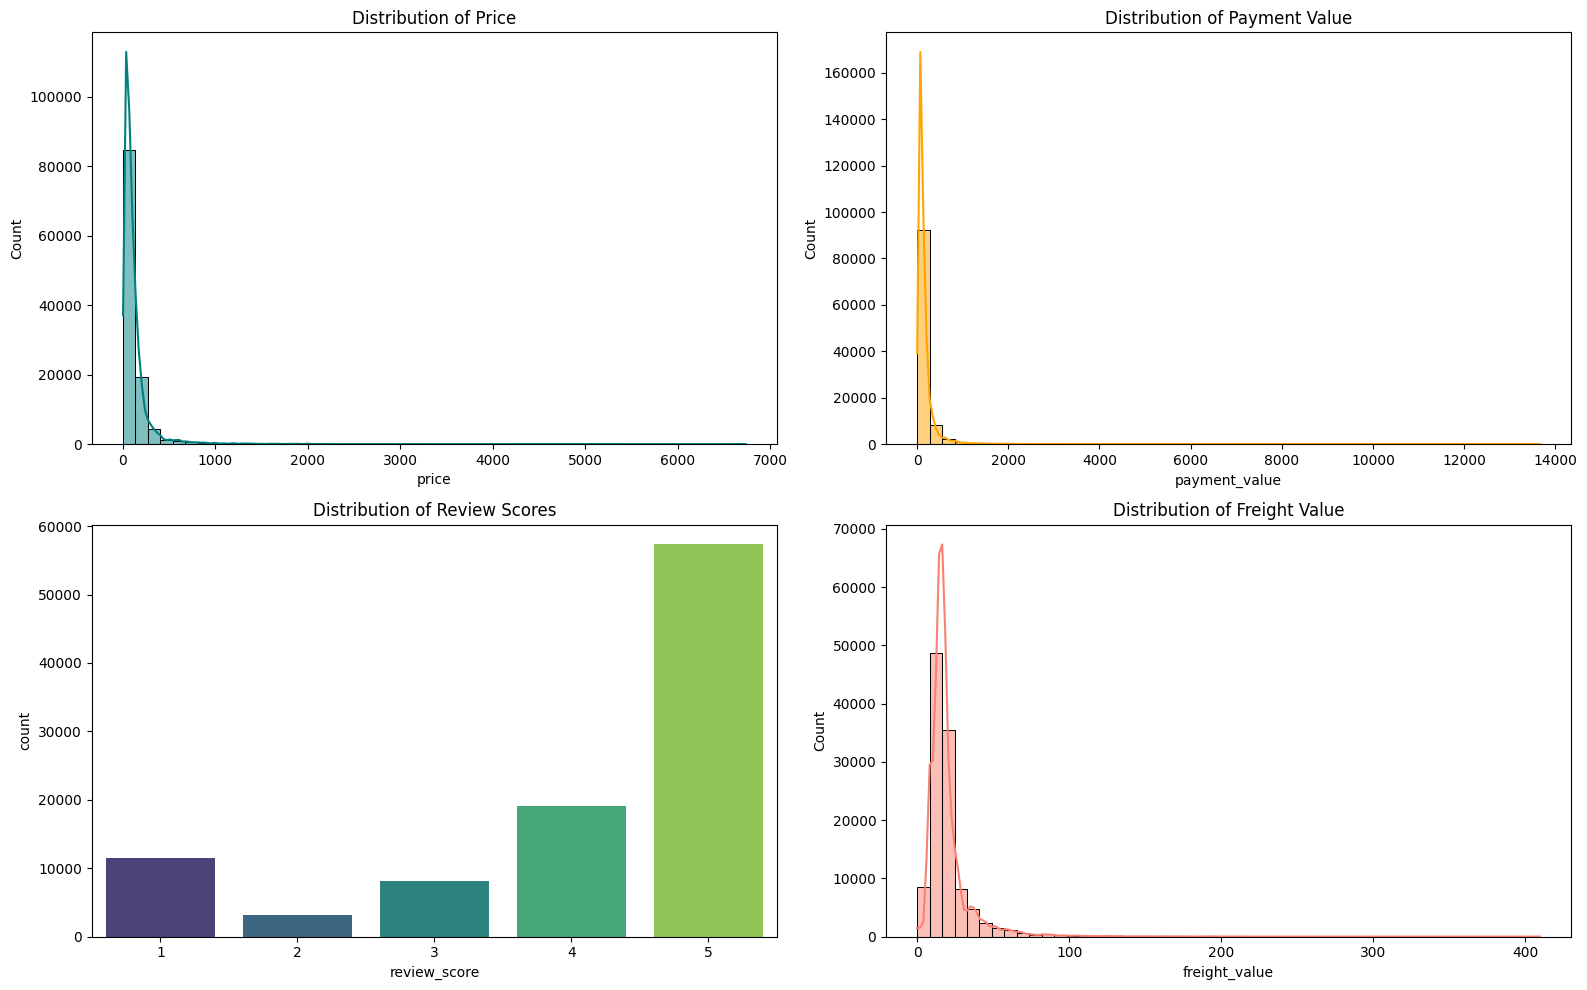

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# Q10: NUMERIC SUMMARY (Describe + Median)
# ============================================
# Mapping tables to their most important numeric columns
numeric_map = {
    'order_items': ['price', 'freight_value'],
    'order_payments': ['payment_value'],
    'order_reviews': ['review_score']
}

print("--- Q10: NUMERIC SUMMARY TABLE ---")
for df_name, cols in numeric_map.items():
    if df_name in globals():
        df = globals()[df_name]
        stats = df[cols].describe().T
        # Add Median specifically as it's often more 'typical' than the mean
        stats['median'] = df[cols].median()
        print(f"\nTable: {df_name.upper()}")
        print(stats[['mean', 'median', 'std', 'min', 'max']])


#  NUMERIC DISTRIBUTIONS (Histograms)
print("\n--- Q11: GENERATING HISTOGRAMS ---")
plt.figure(figsize=(16, 10))

# 1. Price Distribution
plt.subplot(2, 2, 1)
sns.histplot(order_items['price'], bins=50, kde=True, color='teal')
plt.title('Distribution of Price')

# 2. Payment Value Distribution
plt.subplot(2, 2, 2)
sns.histplot(order_payments['payment_value'], bins=50, kde=True, color='orange')
plt.title('Distribution of Payment Value')

# 3. Review Score Distribution (Countplot is better for discrete scores)
plt.subplot(2, 2, 3)
sns.countplot(x='review_score', data=order_reviews, palette='viridis')
plt.title('Distribution of Review Scores')

# 4. Freight Value Distribution
plt.subplot(2, 2, 4)
sns.histplot(order_items['freight_value'], bins=50, kde=True, color='salmon')
plt.title('Distribution of Freight Value')

plt.tight_layout()
plt.show()

--- Q12: OUTLIER IDENTIFICATION (IQR METHOD) ---
          Column  Outlier Count Percentage
0          price           8427       7.5%
1  freight_value          11613      10.3%
2  payment_value           7981       7.7%


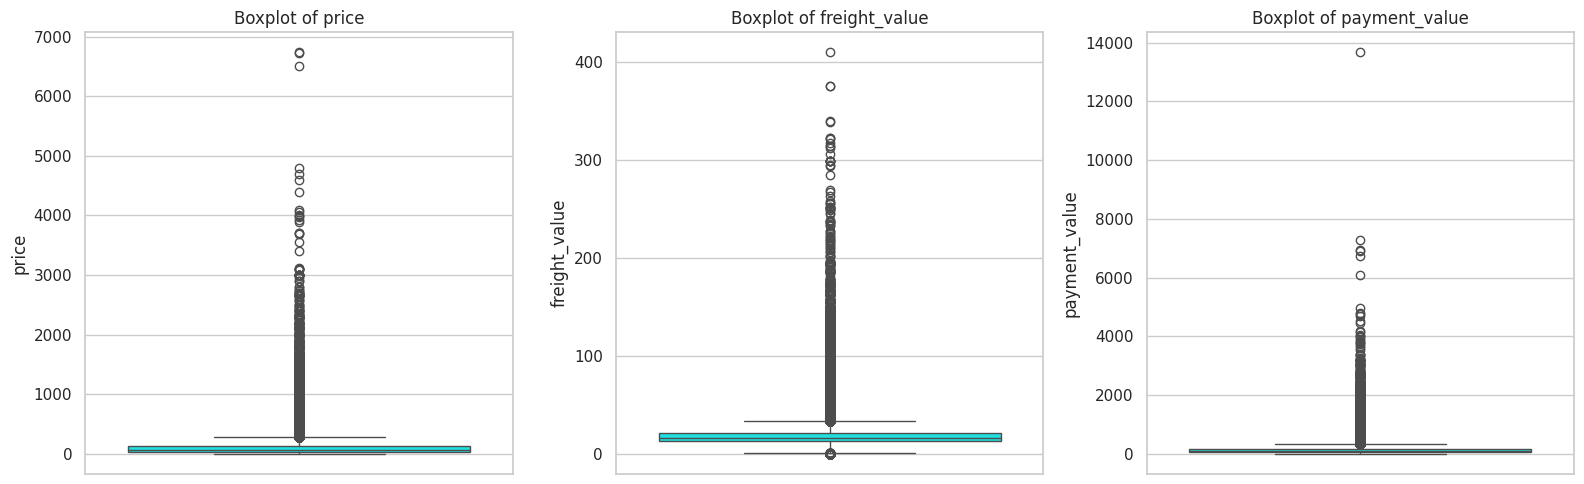

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define numeric columns for outlier check
outlier_map = {
    'order_items': ['price', 'freight_value'],
    'order_payments': ['payment_value']
}

print("--- Q12: OUTLIER IDENTIFICATION (IQR METHOD) ---")
outlier_summary = []
plt.figure(figsize=(16, 5))
plot_num = 1

for table_name, cols in outlier_map.items():
    if table_name in globals():
        df = globals()[table_name]
        for col in cols:
            # Calculate Bounds
            Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
            IQR = Q3 - Q1
            upper_bound = Q3 + 1.5 * IQR

            # Count Outliers
            outliers = df[df[col] > upper_bound]
            count = len(outliers)
            perc = (count / len(df)) * 100

            outlier_summary.append({"Column": col, "Outlier Count": count, "Percentage": f"{perc:.1f}%"})

            # Generate Boxplot
            plt.subplot(1, 3, plot_num)
            sns.boxplot(y=df[col], color='cyan')
            plt.title(f'Boxplot of {col}')
            plot_num += 1

# Display Summary
print(pd.DataFrame(outlier_summary))
plt.tight_layout()
plt.savefig('q12_boxplots.png')

In [35]:
# Q14: RARE CATEGORIES (Threshold < 3%)

# Create df_merged by joining the key tables
df_merged = order_items.merge(order_payments, on='order_id', how='left')
df_merged = df_merged.merge(order_reviews, on='order_id', how='left')
df_merged = df_merged.merge(products, on='product_id', how='left')

print(f"Success! df_merged created with {df_merged.shape[0]} rows.")

Success! df_merged created with 118304 rows.


In [36]:
# # ============================================
# Q14: RARE CATEGORIES (< 3%)
# ============================================
# 1. Calculate percentage share
cat_shares = df_merged['product_category_name'].value_counts(normalize=True) * 100

# 2. Identify rare categories (Threshold < 3%)
rare_list = cat_shares[cat_shares < 3]

print("--- Q14: RARE CATEGORY REPORT ---")
print(f"Number of categories appearing < 3% of the time: {len(rare_list)}")
print("\n RARE LIST (Sample):")
print(rare_list.head(10))

# Deliverable logic
print("\n DECISION: Group these into an 'Other' category.")
print(" WHY: To reduce 'cardinality noise' in multivariate plots and ensure statistical significance.")

--- Q14: RARE CATEGORY REPORT ---
Number of categories appearing < 3% of the time: 61

 RARE LIST (Sample):
product_category_name
bebes                                2.708277
eletronicos                          2.405667
papelaria                            2.218015
fashion_bolsas_e_acessorios          1.834258
pet_shop                             1.715918
moveis_escritorio                    1.511361
Unknown                              1.444583
consoles_games                       1.006728
malas_acessorios                     0.983061
construcao_ferramentas_construcao    0.807242
Name: proportion, dtype: float64

 DECISION: Group these into an 'Other' category.
 WHY: To reduce 'cardinality noise' in multivariate plots and ensure statistical significance.


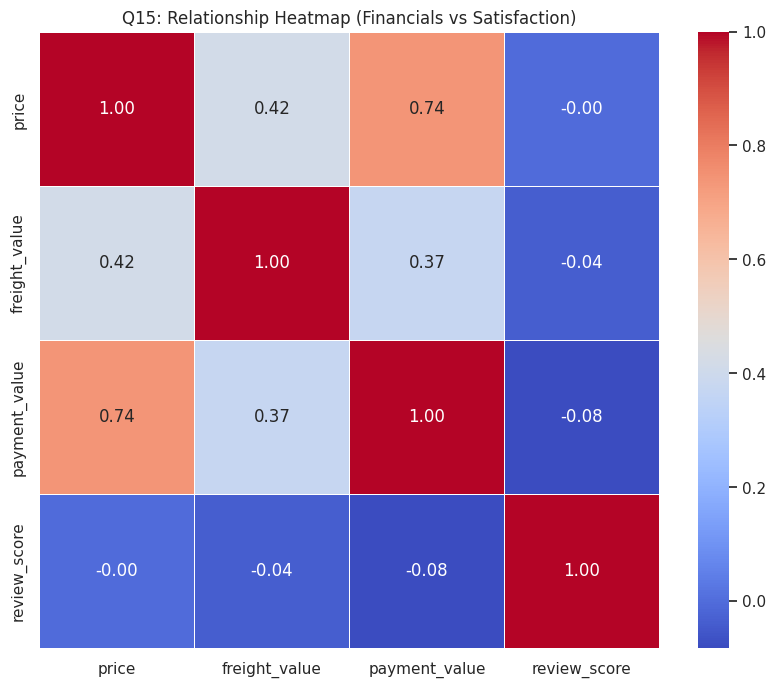

In [37]:

# Q15: CORRELATION HEATMAP
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for numeric columns only
corr_cols = ['price', 'freight_value', 'payment_value', 'review_score']
corr_matrix = df_merged[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Q15: Relationship Heatmap (Financials vs Satisfaction)")
plt.show()

--- Q15: NUMERIC RELATIONSHIPS REPORT ---

1. CORRELATION MATRIX:


,price,freight_value,payment_value,review_score,product_name_lenght,product_description_lenght,product_photos_qty
price,1.000,0.416,0.739,-0.004,0.018,0.202,0.053
freight_value,0.416,1.000,0.374,-0.037,0.023,0.096,0.022
payment_value,0.739,0.374,1.000,-0.082,0.002,0.156,0.010
review_score,-0.004,-0.037,-0.082,1.000,-0.006,0.011,0.022
product_name_lenght,0.018,0.023,0.002,-0.006,1.000,0.090,0.145
product_description_lenght,0.202,0.096,0.156,0.011,0.090,1.000,0.118
product_photos_qty,0.053,0.022,0.010,0.022,0.145,0.118,1.000



2. TOP 5 STRONGEST CORRELATIONS:
   1. price & payment_value: 0.739
   2. freight_value & price: 0.416
   3. payment_value & freight_value: 0.374
   4. price & product_description_lenght: 0.202
   5. payment_value & product_description_lenght: 0.156


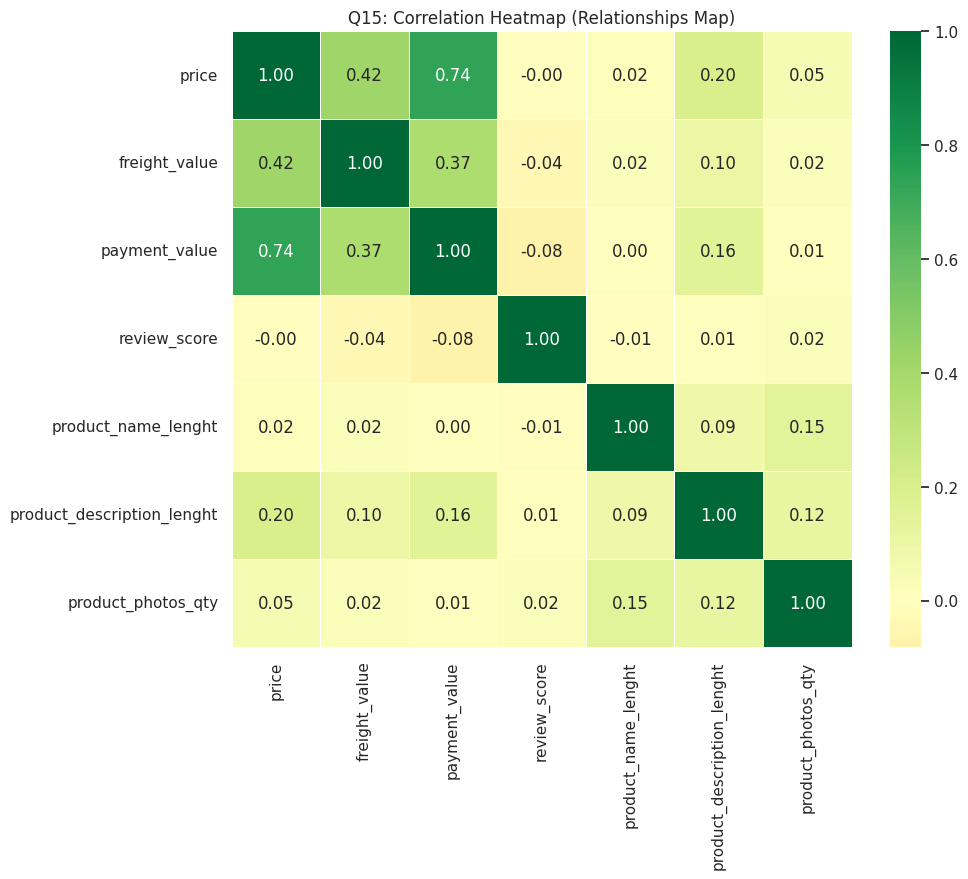

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================
# Q15: CORRELATION MATRIX & TOP 5 RELATIONSHIPS
# ============================================

# 1. Select the most relevant numeric columns
# We focus on Financials, Ratings, and Product Metadata
target_cols = ['price', 'freight_value', 'payment_value', 'review_score',
               'product_name_lenght', 'product_description_lenght', 'product_photos_qty']

# 2. Compute the Correlation Matrix
corr_matrix = df_merged[target_cols].corr()

# 3. Identify Top 5 strongest correlations (excluding self-correlation)
# Unstack and sort to find the highest absolute values
corr_unstacked = corr_matrix.unstack()
# Filter out self-correlation (e.g., price vs price)
corr_unstacked = corr_unstacked[corr_unstacked.index.get_level_values(0) !=
                                corr_unstacked.index.get_level_values(1)]

# Take absolute values to find strongest relationships (positive or negative)
top_5_pairs = corr_unstacked.abs().sort_values(ascending=False).drop_duplicates().head(5)

print("--- Q15: NUMERIC RELATIONSHIPS REPORT ---")
print("\n1. CORRELATION MATRIX:")
display(corr_matrix.round(3))

print("\n2. TOP 5 STRONGEST CORRELATIONS:")
for i, ((col1, col2), val) in enumerate(top_5_pairs.items()):
    actual_val = corr_matrix.loc[col1, col2]
    print(f"   {i+1}. {col1} & {col2}: {actual_val:.3f}")

# 3. Visualization: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt=".2f", linewidths=0.5)
plt.title("Q15: Correlation Heatmap (Relationships Map)")
plt.savefig('q15_correlation_heatmap.png')
plt.show()

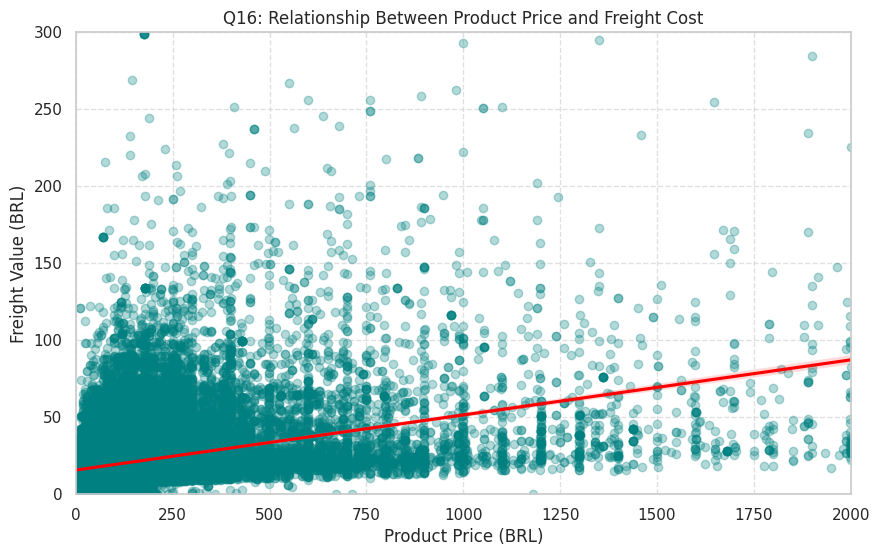

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# Q16: SCATTER PLOT (Price vs Freight)
# ============================================

plt.figure(figsize=(10, 6))

# Using a scatter plot with a regression line to see the trend
sns.regplot(data=df_merged, x='price', y='freight_value',
            scatter_kws={'alpha':0.3, 'color':'teal'},
            line_kws={'color':'red'})

plt.title('Q16: Relationship Between Product Price and Freight Cost')
plt.xlabel('Product Price (BRL)')
plt.ylabel('Freight Value (BRL)')

# Zooming in slightly to see the dense part of the data
plt.xlim(0, 2000)
plt.ylim(0, 300)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

--- Q17: TOP 10 CATEGORIES BY PRICE ---
                          mean  median     std  count
product_category_name                                
relogios_presentes      201.89  129.00  257.57   6213
automotivo              140.54   85.74  215.12   4400
beleza_saude            129.78   79.90  180.36  10032
informatica_acessorios  116.57   81.50  171.07   8150
esporte_lazer           114.35   76.49  162.47   9003
ferramentas_jardim      113.05   59.90  199.57   4588
cama_mesa_banho          92.36   78.90   80.41  11988
utilidades_domesticas    90.63   59.70  140.19   7380
moveis_decoracao         87.42   65.00   88.94   8832
telefonia                71.85   29.99  135.83   4726


/tmp/ipykernel_478/3430744863.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top, x='price', y='product_category_name',


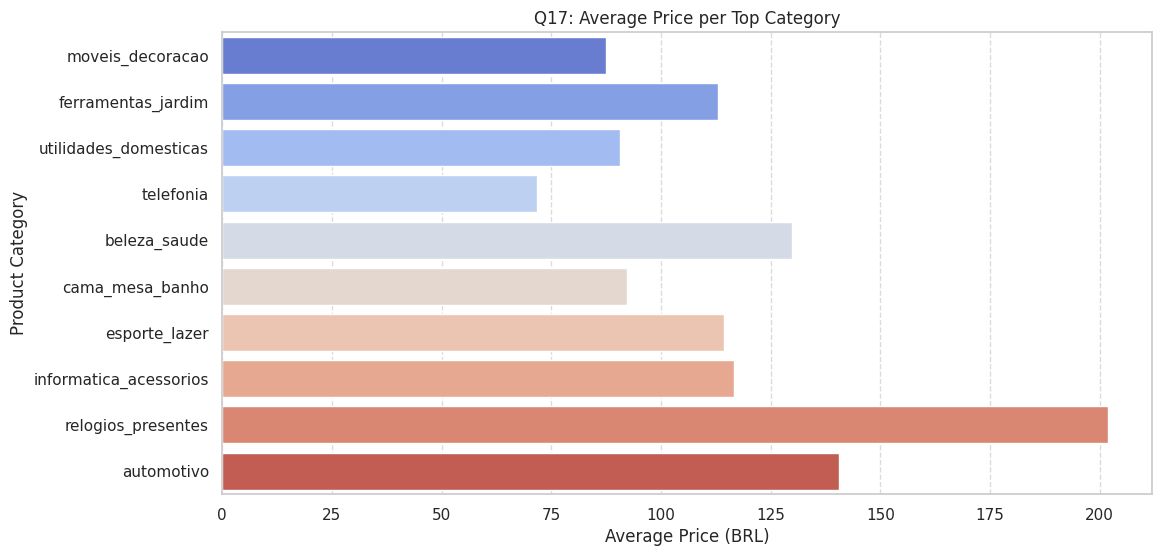

In [40]:
# ============================================
# Q17: CATEGORY VS. PRICE (Grouped Analysis)
# ============================================

# 1. Identify the Top 10 categories by order volume
top_10_cats = df_merged['product_category_name'].value_counts().head(10).index

# 2. Filter df_merged to only include these top categories
df_top = df_merged[df_merged['product_category_name'].isin(top_10_cats)]

# 3. Compute Grouped Mean and Median
category_stats = df_top.groupby('product_category_name')['price'].agg(['mean', 'median', 'std', 'count'])
category_stats = category_stats.sort_values(by='mean', ascending=False)

print("--- Q17: TOP 10 CATEGORIES BY PRICE ---")
print(category_stats.round(2))

# 4. Visualization: Bar Chart of Mean Price
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top, x='price', y='product_category_name',
            estimator='mean', errorbar=None, palette='coolwarm')

plt.title('Q17: Average Price per Top Category')
plt.xlabel('Average Price (BRL)')
plt.ylabel('Product Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

--- Q18: CATEGORY QUALITY CROSSTAB (%) ---
review_score             1.0  2.0   3.0   4.0   5.0
product_category_name                              
automotivo              11.8  3.5   7.7  20.8  56.3
beleza_saude            11.4  2.5   7.8  17.8  60.6
cama_mesa_banho         14.6  4.7   9.8  18.8  52.0
esporte_lazer           11.9  2.7   7.4  18.9  59.1
ferramentas_jardim      13.2  3.1   8.0  19.3  56.3
informatica_acessorios  14.8  3.6   8.5  19.5  53.6
moveis_decoracao        14.9  4.5   8.9  18.0  53.7
relogios_presentes      12.7  3.7   8.9  18.7  56.0
telefonia               12.8  4.0  10.1  21.8  51.3
utilidades_domesticas   11.9  3.6   8.5  18.7  57.3


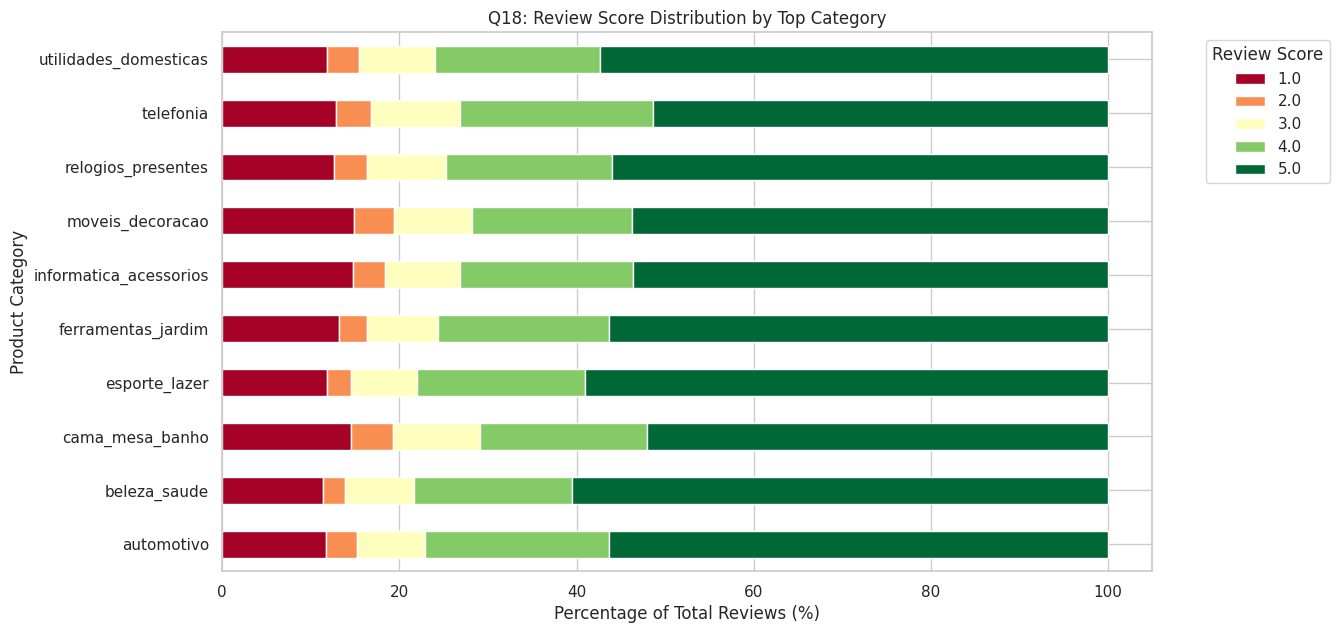

In [41]:
# ============================================
# Q18: CATEGORY vs. REVIEW SCORE (Crosstab)
# ============================================

# 1. Focus on the Top 10 most frequent categories
top_10_cats = df_merged['product_category_name'].value_counts().head(10).index
df_top = df_merged[df_merged['product_category_name'].isin(top_10_cats)]

# 2. Create the Crosstab (Normalized to 100% per category)
# This shows the percentage distribution of scores for each category
quality_crosstab = pd.crosstab(df_top['product_category_name'],
                               df_top['review_score'],
                               normalize='index') * 100

print("--- Q18: CATEGORY QUALITY CROSSTAB (%) ---")
print(quality_crosstab.round(1))

# 3. Visualization: Stacked Bar Chart
quality_crosstab.plot(kind='barh', stacked=True, figsize=(12, 7),
                      colormap='RdYlGn')

plt.title('Q18: Review Score Distribution by Top Category')
plt.xlabel('Percentage of Total Reviews (%)')
plt.ylabel('Product Category')
plt.legend(title='Review Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

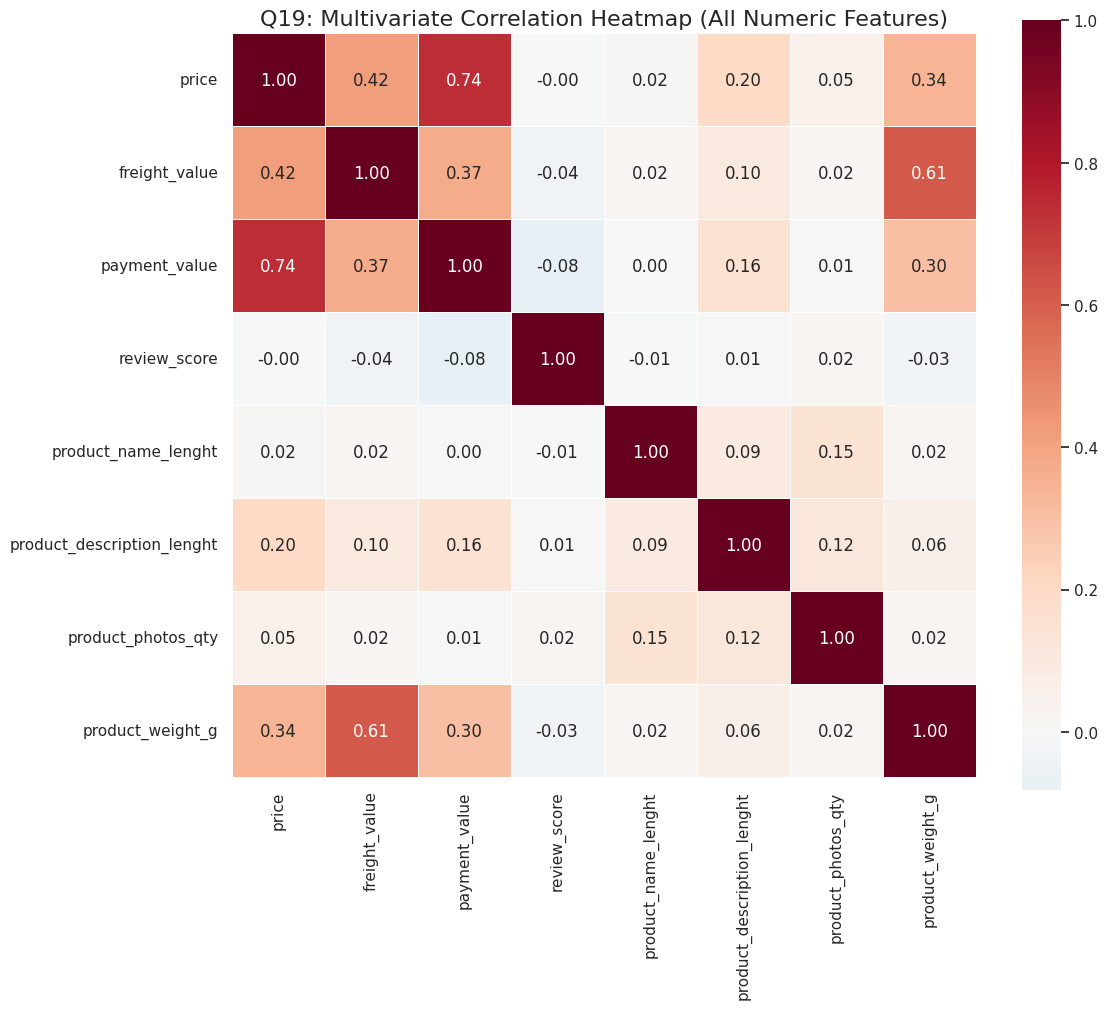

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ============================================
# Q19: MULTIVARIATE CORRELATION HEATMAP
# ============================================

# Selecting all key numeric features for a holistic view
multivariate_cols = [
    'price', 'freight_value', 'payment_value', 'review_score',
    'product_name_lenght', 'product_description_lenght',
    'product_photos_qty', 'product_weight_g'
]

# Compute the full correlation matrix
# Ensure df_merged contains these columns from previous steps
corr_full = df_merged[multivariate_cols].corr()

plt.figure(figsize=(12, 10))

# Create the heatmap with a diverging color palette
sns.heatmap(corr_full, annot=True, cmap='RdBu_r', center=0,
            fmt=".2f", linewidths=0.5, square=True)

plt.title('Q19: Multivariate Correlation Heatmap (All Numeric Features)', fontsize=16)
plt.show()

In [43]:
# Check if notebook is saved to Drive
import os
print(f"Notebook location: {os.getcwd()}")

Notebook location: /content
